# Visium-HD Pre-process v2

In [125]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: ANYWIDGET_HMR=1


In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import celldega as dega

import os
import json
import h5py
import matplotlib.pyplot as plt
from PIL import Image

In [127]:
# from http.server import HTTPServer, SimpleHTTPRequestHandler
# import threading as thr
# import requests as rq

# Pre-process LandscapeFiles

In [128]:
dataset = 'Visium_HD_Human_Pancreas_binned_outputs'

# base_path = 'data/visium-hd_data/Visium_HD_Mouse_Lung_Fresh_Frozen_binned_outputs/square_008um/'
base_path = 'data/visium-hd_data/' + dataset + '/binned_outputs/square_008um/'

# landscape_files_path = 'data/visium-hd_landscapes/Visium_HD_Human_Lung_Cancer/'
landscape_files_path = 'data/landscape_files/' + dataset + '/'

# Tile Positions

In [129]:
df_pos = pd.read_parquet(base_path + 'spatial/tissue_positions.parquet')

In [130]:
df_pos = df_pos[df_pos['in_tissue'] == 1]

In [131]:
df_pos['in_tissue'].value_counts()

in_tissue
1    421485
Name: count, dtype: int64

In [132]:
df_pos.head()

,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
341,s_008um_00000_00341-1,1,0,341,10318.098267,30455.431387
342,s_008um_00000_00342-1,1,0,342,10318.409136,30426.210350
415,s_008um_00000_00415-1,1,0,415,10341.102619,28293.071787
416,s_008um_00000_00416-1,1,0,416,10341.413490,28263.850671
417,s_008um_00000_00417-1,1,0,417,10341.724360,28234.629554


In [133]:
df_pos.shape[0]/1e6

0.421485

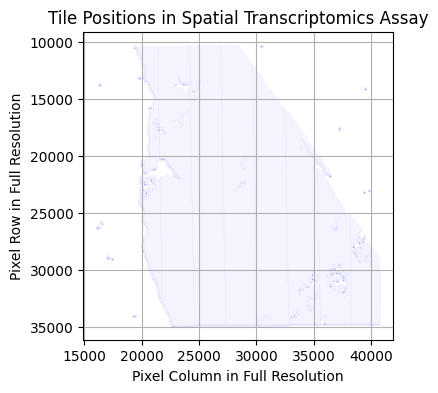

In [134]:
# Plotting
plt.figure(figsize=(4, 4))
plt.scatter(df_pos['pxl_col_in_fullres'], df_pos['pxl_row_in_fullres'], c='blue', alpha=0.6, edgecolors='w', s=2)
plt.title('Tile Positions in Spatial Transcriptomics Assay')
plt.xlabel('Pixel Column in Full Resolution')
plt.ylabel('Pixel Row in Full Resolution')
plt.gca().invert_yaxis()  # Invert y-axis to match the image coordinates
plt.grid(True)
plt.show()

In [135]:
import json

In [136]:
filepath_scalefactors = base_path + 'spatial/scalefactors_json.json'
with open(filepath_scalefactors) as file:
    data = json.load(file)

print(data)

{'spot_diameter_fullres': 29.213751332108963, 'bin_size_um': 8.0, 'microns_per_pixel': 0.2738436399028003, 'tissue_lowres_scalef': 0.011605191, 'fiducial_diameter_fullres': 1205.0672424494946, 'tissue_hires_scalef': 0.11605191, 'regist_target_img_scalef': 0.11605191}


In [137]:
scale_factor = data['tissue_hires_scalef']

In [138]:
scale_factor

0.11605191

In [139]:
data['microns_per_pixel']

0.2738436399028003

In [140]:
df_pos['x_scaled'] = df_pos['pxl_col_in_fullres'] * scale_factor
df_pos['y_scaled'] = df_pos['pxl_row_in_fullres'] * scale_factor

In [141]:
print(df_pos.x_scaled.min(), df_pos.x_scaled.max())
print(df_pos.y_scaled.min(), df_pos.y_scaled.max())

1871.9184733822326 4721.150511399241
1197.435011451575 4045.8028701778294


In [142]:
df_pos.shape

(421485, 8)

In [143]:
# Sample 10% of the rows randomly
df_sample = df_pos.sample(frac=0.01)

In [144]:
df_sample.shape

(4215, 8)

In [145]:
# image_path = base_path + 'spatial/tissue_hires_image.png'
# print(image_path)
# # img = Image.open(image_path)
# img = Image.open('data/visium-hd_data/Visium_HD_Mouse_Lung_Fresh_Frozen_binned_outputs/square_008um/spatial/tissue_hires_image.png')

In [146]:
# # Create a plot with the image
# fig, ax = plt.subplots(figsize=(10, 12))
# ax.imshow(img)

# # Scatter plot of the sampled data points
# ax.scatter(df_sample['x_scaled'], df_sample['y_scaled'], color='red', s=0.1, alpha=1)

# # Display the plot
# plt.show()


In [147]:
meta_tile = pd.read_csv(base_path + 'analysis/clustering/gene_expression_graphclust/clusters.csv')
meta_tile

,Barcode,Cluster
0,s_008um_00172_00448-1,1
1,s_008um_00269_00526-1,5
2,s_008um_00547_00611-1,1
3,s_008um_00693_00628-1,3
4,s_008um_00260_00253-1,1
...,...,...
421098,s_008um_00708_00481-1,1
421099,s_008um_00807_00122-1,2
421100,s_008um_00003_00520-1,2
421101,s_008um_00247_00283-1,1


In [148]:
from matplotlib.colors import to_hex
# Get all categorical color palettes from Matplotlib and flatten them into a single list of colors
palettes = [plt.get_cmap(name).colors for name in plt.colormaps() if "tab" in name]
flat_colors = [color for palette in palettes for color in palette]

# Convert RGB tuples to hex codes
flat_colors_hex = [to_hex(color) for color in flat_colors]

In [149]:
meta_tile['Cluster'].value_counts()

Cluster
1     144054
2      78448
3      53923
4      43710
5      31741
6      28904
7      22357
8       7641
9       3575
10      2657
11      2136
12      1142
13       418
14       397
Name: count, dtype: int64

In [150]:
if not os.path.exists(landscape_files_path):
    os.mkdir(landscape_files_path)

In [151]:
clusters = [str(x) for x in meta_tile['Cluster'].unique().tolist()]

# Use modular arithmetic to assign a color to each gene, white for genes with "Blank"
colors = [flat_colors_hex[i % len(flat_colors_hex)] if "Blank" not in cluster else "#FFFFFF" for i, cluster in enumerate(clusters)]

# Create a DataFrame with genes and their assigned colors
df_colors = pd.DataFrame({'color': colors}, index=clusters)

df_colors.to_parquet(landscape_files_path + 'df_colors.parquet')

In [152]:
df_colors.head()

,color
1,#1f77b4
5,#ff7f0e
3,#2ca02c
7,#d62728
4,#9467bd


In [153]:
# meta_tile_json = meta_tile.to_json(orient='records')
meta_tile_json = dict(zip(meta_tile['Barcode'], meta_tile['Cluster']))

json_output = json.dumps(meta_tile_json)

with open(landscape_files_path + 'meta_tile.json', 'w') as file:
    file.write(json_output)

In [154]:
meta_tile.head()

,Barcode,Cluster
0,s_008um_00172_00448-1,1
1,s_008um_00269_00526-1,5
2,s_008um_00547_00611-1,1
3,s_008um_00693_00628-1,3
4,s_008um_00260_00253-1,1


In [155]:
tile = pd.DataFrame()
tile['name'] = df_pos['barcode']

# tile['center_x'] = df_pos['pxl_col_in_fullres'].round(1)
# tile['center_y'] = df_pos['pxl_row_in_fullres'].round(1)

tile['center_x'] = df_pos['x_scaled'] # .round(1)
tile['center_y'] = df_pos['y_scaled'] # .round(1)

tile['center_x'] = tile['center_x'].astype(float)
tile['center_y'] = tile['center_y'].astype(float)

In [156]:
# path_tile_geo = landscape_files_path + 'tile_geometries.parquet'
path_tile_geo = landscape_files_path + 'tile_geometries.parquet'

In [157]:
# pd.read_parquet(base_path + 'landscape_files/tile_geometries.parquet')

In [158]:
from copy import deepcopy

In [159]:
tile_merge = deepcopy(tile)
tile_merge.index = tile['name'].values.tolist()

In [160]:
tile_merge.head()

,name,center_x,center_y
s_008um_00000_00341-1,s_008um_00000_00341-1,3534.410982,1197.435011
s_008um_00000_00342-1,s_008um_00000_00342-1,3531.019825,1197.471088
s_008um_00000_00415-1,s_008um_00000_00415-1,3283.465021,1200.104710
s_008um_00000_00416-1,s_008um_00000_00416-1,3280.073854,1200.140788
s_008um_00000_00417-1,s_008um_00000_00417-1,3276.682688,1200.176865


In [161]:
meta_tile_merge = deepcopy(meta_tile)

In [162]:
meta_tile_merge.index = meta_tile['Barcode'].values.tolist()
meta_tile_merge.head()

,Barcode,Cluster
s_008um_00172_00448-1,s_008um_00172_00448-1,1
s_008um_00269_00526-1,s_008um_00269_00526-1,5
s_008um_00547_00611-1,s_008um_00547_00611-1,1
s_008um_00693_00628-1,s_008um_00693_00628-1,3
s_008um_00260_00253-1,s_008um_00260_00253-1,1


In [163]:
cats = [str(x) for x in meta_tile_merge['Cluster'].values.tolist()]

In [164]:
keep_tiles = meta_tile_merge.index.tolist()
tile_merge.loc[keep_tiles, 'cluster'] = pd.Series(cats, index=keep_tiles)

In [165]:
tile_merge.head()

,name,center_x,center_y,cluster
s_008um_00000_00341-1,s_008um_00000_00341-1,3534.410982,1197.435011,5
s_008um_00000_00342-1,s_008um_00000_00342-1,3531.019825,1197.471088,5
s_008um_00000_00415-1,s_008um_00000_00415-1,3283.465021,1200.104710,1
s_008um_00000_00416-1,s_008um_00000_00416-1,3280.073854,1200.140788,4
s_008um_00000_00417-1,s_008um_00000_00417-1,3276.682688,1200.176865,1


In [166]:
tile_merge.to_parquet(landscape_files_path + 'meta_tile.parquet')

In [167]:
tile_merge.center_x.mean()

3332.8640716844134

In [168]:
tile_merge.center_y.mean()

2800.0239757510085

In [169]:
tile_merge['geometry'] = tile_merge.apply(lambda row: [row['center_x'], row['center_y']], axis=1)
tile_merge.loc[keep_tiles, ['name', 'geometry', 'cluster']].to_parquet(path_tile_geo) 

In [170]:
tile_merge.head()

,name,center_x,center_y,cluster,geometry
s_008um_00000_00341-1,s_008um_00000_00341-1,3534.410982,1197.435011,5,"[3534.4109822908545, 1197.435011451575]"
s_008um_00000_00342-1,s_008um_00000_00342-1,3531.019825,1197.471088,5,"[3531.0198252157843, 1197.471088417059]"
s_008um_00000_00415-1,s_008um_00000_00415-1,3283.465021,1200.104710,1,"[3283.4650206412052, 1200.1047104942324]"
s_008um_00000_00416-1,s_008um_00000_00416-1,3280.073854,1200.140788,4,"[3280.073854303266, 1200.14078755826]"
s_008um_00000_00417-1,s_008um_00000_00417-1,3276.682688,1200.176865,1,"[3276.682687840153, 1200.176864623619]"


In [171]:
path_tile_geo

'data/landscape_files/Visium_HD_Human_Pancreas_binned_outputs/tile_geometries.parquet'

In [172]:
pd.read_parquet(path_tile_geo).head()

,name,geometry,cluster
s_008um_00172_00448-1,s_008um_00172_00448-1,"[3177.7931013089665, 1784.5857800929148]",1
s_008um_00269_00526-1,s_008um_00269_00526-1,"[2916.7978923164123, 2116.35075773132]",5
s_008um_00547_00611-1,s_008um_00547_00611-1,"[2638.6250007684025, 3062.18814018659]",1
s_008um_00693_00628-1,s_008um_00693_00628-1,"[2586.2674667970755, 3557.9278437733733]",3
s_008um_00260_00253-1,s_008um_00260_00253-1,"[3842.2615331547267, 2075.9760874985845]",1


In [173]:
base_path

'data/visium-hd_data/Visium_HD_Human_Pancreas_binned_outputs/binned_outputs/square_008um/'

In [174]:
file_path = base_path + 'filtered_feature_bc_matrix.h5'

In [175]:
# def print_structure(file, indent = ' '):
#     """Recursively prints the groups and datasets in an HDF5 file."""
#     for key in file.keys():
#         item = file[key]
#         print(indent, key)
#         if isinstance(item, h5py.Dataset):
#             print(indent + ' ', "Dataset")
#         elif isinstance(item, h5py.Group):
#             print_structure(item, indent + ' ')
            
# with h5py.File(file_path, 'r') as file:
#     print_structure(file)


# Read Tile-by-Gene Sparse Matrix

In [176]:
import pandas as pd
from scipy.io import mmread
from scipy.sparse import csr_matrix

In [177]:
def make_unique(names):
    from collections import Counter
    counts = Counter(names)
    new_names = []
    used_names = {}
    
    for name in names:
        if counts[name] > 1:  # If this name is a duplicate
            if name in used_names:
                used_names[name] += 1
            else:
                used_names[name] = 1
            new_name = f"{name}-{used_names[name]}"
        else:
            new_name = name
        new_names.append(new_name)
    
    return new_names

In [178]:
%%time
# File paths
barcodes_path = base_path + 'filtered_feature_bc_matrix/barcodes.tsv.gz'
features_path = base_path + 'filtered_feature_bc_matrix/features.tsv.gz'
matrix_path = base_path + 'filtered_feature_bc_matrix/matrix.mtx.gz'

# Read barcodes and features
barcodes = pd.read_csv(barcodes_path, header=None, compression='gzip')
features = pd.read_csv(features_path, header=None, compression='gzip', sep='\t')

# Read the gene expression matrix and transpose it
matrix = mmread(matrix_path).transpose().tocsc()  # Transpose and convert to CSC

# Create a sparse DataFrame with genes as columns and barcodes as rows
tbg = pd.DataFrame.sparse.from_spmatrix(matrix, index=barcodes[0], columns=features[1])

tbg.columns = make_unique(tbg.columns.tolist())

print(tbg.shape)

(421485, 18132)
CPU times: user 4.86 s, sys: 295 ms, total: 5.16 s
Wall time: 2.27 s


In [179]:
tbg.columns.tolist()[:10]

['SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'PERM1',
 'HES4',
 'ISG15',
 'AGRN',
 'RNF223',
 'C1orf159']

In [180]:
meta_tile = pd.read_parquet(landscape_files_path + 'meta_tile.parquet')
meta_tile.head()

,name,center_x,center_y,cluster
s_008um_00000_00341-1,s_008um_00000_00341-1,3534.410982,1197.435011,5
s_008um_00000_00342-1,s_008um_00000_00342-1,3531.019825,1197.471088,5
s_008um_00000_00415-1,s_008um_00000_00415-1,3283.465021,1200.104710,1
s_008um_00000_00416-1,s_008um_00000_00416-1,3280.073854,1200.140788,4
s_008um_00000_00417-1,s_008um_00000_00417-1,3276.682688,1200.176865,1


In [181]:
tbg.head()

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-CO1,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
0,,,,,,,,,,,,,,,,,,,,,
s_008um_00172_00448-1,0,1,0,0,0,0,0,0,0,0,...,0,2,1,4,0,0,2,0,1,1
s_008um_00269_00526-1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,2,0,0,0,0,0,0
s_008um_00547_00611-1,0,0,0,0,0,0,0,0,0,0,...,1,1,2,0,0,1,0,1,0,0
s_008um_00693_00628-1,0,0,0,0,0,0,0,0,0,0,...,3,2,7,5,0,1,1,0,0,2
s_008um_00260_00253-1,0,0,0,0,0,0,0,0,0,0,...,2,1,1,0,0,1,2,0,0,4


In [182]:
gene_exp = tbg.sum()

In [183]:
%%time
# Calculate mean expression across tiles with float precision
print('calculating mean expression from sparse float data')
mean_expression = tbg.astype(pd.SparseDtype("float", 0)).mean(axis=0)

# Calculate the variance as the average of the squared deviations
print('calculating variance by looping over rows')
num_tiles = tbg.shape[1]
variance = tbg.apply(lambda x: ((x - mean_expression[x.name]) ** 2).sum() / num_tiles, axis=0)
std_deviation = np.sqrt(variance)

# # Assuming mean_expression is aligned with columns
# print('calculating variance using vectorized approach')
# squared_deviations = (tbg - mean_expression) ** 2
# variance = squared_deviations.mean(axis=0)

# Calculate maximum expression
max_expression = tbg.max(axis=0)

# Calculate proportion of tiles with non-zero expression
proportion_nonzero = (tbg != 0).sum(axis=0) / len(tbg)

# Create a DataFrame to hold all these metrics
meta_gene = pd.DataFrame({
    'mean': mean_expression,
    'std': std_deviation,
    'max': max_expression,
    'non-zero': proportion_nonzero
})

calculating mean expression from sparse float data
calculating variance by looping over rows
CPU times: user 7.93 s, sys: 504 ms, total: 8.44 s
Wall time: 8.53 s


In [184]:
meta_gene.head()

,mean,std,max,non-zero
SAMD11,0.000294,0.083349,2,0.000002
NOC2L,0.006691,0.396121,2,0.000002
KLHL17,0.001343,0.177495,2,0.000002
PLEKHN1,0.000161,0.061235,1,0.000002
PERM1,0.000076,0.042008,1,0.000002


In [185]:
meta_gene['max'].sort_values(ascending=False).head(10)

PNLIP     913
PRSS1     666
CLPS      493
CPA1      389
INS       343
CELA3A    284
CPB1      264
CEL       244
REG3A     178
CTRB2     168
Name: max, dtype: Sparse[int64, 0]

In [186]:
# Convert only the sparse columns to dense
for column in meta_gene.columns:
    # Check if the column dtype is an instance of pd.SparseDtype
    if isinstance(meta_gene[column].dtype, pd.SparseDtype):
        meta_gene[column] = meta_gene[column].sparse.to_dense()

In [187]:
meta_gene.to_parquet(landscape_files_path + 'meta_gene.parquet')

In [188]:
%%time
mean_expression = tbg.astype(pd.SparseDtype("float", 0)).mean(axis=0)
mean_expression

CPU times: user 1.29 s, sys: 70.2 ms, total: 1.36 s
Wall time: 1.37 s


SAMD11     0.000294
NOC2L      0.006691
KLHL17     0.001343
PLEKHN1    0.000161
PERM1      0.000076
             ...   
MT-ND4L    1.326977
MT-ND4     1.351277
MT-ND5     0.239302
MT-ND6     0.245869
MT-CYB     1.544601
Length: 18132, dtype: Sparse[float64, 0]

In [189]:
mean_expression.sort_values(ascending=False).head(5)

PNLIP    77.489092
PRSS1    65.933713
CLPS     51.287256
CPA1     36.838841
CPB1     30.689726
dtype: Sparse[float64, 0]

# save tile-by-gene parquet files

In [190]:
# need to run this just commenting out to prevent re-running
################################################################
output_dir = landscape_files_path + 'tbg/'
os.makedirs(output_dir, exist_ok=True)  

for index, gene in enumerate(tbg.columns):
    if index % 500 == 0:
        print(index)
    # Extract the column as a DataFrame
    col_df = tbg[[gene]].copy()

    col_df = col_df.sparse.to_dense()
    # col_df.fillna(0, inplace=True)    
    col_df = col_df.astype(int)

    inst_df = pd.DataFrame(col_df.values, columns=[gene], index=col_df.index.tolist())    

    inst_df = inst_df.loc[keep_tiles]
    inst_df.replace(0, pd.NA, inplace=True)
    inst_df.dropna(how='all', inplace=True)    
    
    # Save to Parquet
    inst_df.to_parquet(os.path.join(output_dir, f'{gene}.parquet'))


0


KeyboardInterrupt: 

In [ ]:
pd.read_parquet(landscape_files_path + 'tbg/Abca1.parquet').head()

### Make Image Pyramid

In [ ]:
dega.pre.make_deepzoom_pyramid(
    base_path + 'spatial/tissue_hires_image.png', 
    landscape_files_path + 'pyramid_images/', 
    'cells', 
    suffix=".webp[Q=100]"
)

In [ ]:
# Example usage:
path_image_pyramid = landscape_files_path + 'pyramid_images/cells_files/'
max_pyramid_zoom = dega.pre.get_max_zoom_level(path_image_pyramid)

print(max_pyramid_zoom)

In [ ]:
landscape_files_path.strip('/')

In [ ]:
image_info = {
        "name": "cells",
        "button_name": "CELLS",
        "color": [0, 0, 255]
    }

In [ ]:
dega.pre.save_landscape_parameters(
    'Visium-HD', 
    landscape_files_path.strip('/'),
    'cells_files',
    tile_size=100,
    image_info=image_info
)

# Landscape Visualization

In [ ]:
server_address = dega.viz.get_local_server()

In [ ]:
base_url = f'http://localhost:{server_address}/data/landscape_files/' + dataset

In [ ]:
# landscape_sst = dega.viz.Landscape(
#     technology='Visium-HD', 
#     base_url=base_url, 
#     ini_x=3000, 
#     ini_y=4000, 
#     ini_z=0, 
#     ini_zoom=-3, 
#     square_tile_size=1.25,
#     # width=500
# )
# landscape_sst

In [ ]:
tbg

In [ ]:
meta_tile

In [ ]:
# list_ser = []

# for inst_cluster in meta_tile.cluster.unique():

#     if inst_cluster != None:

#         keep_tiles = meta_tile[meta_tile.cluster == inst_cluster].index.tolist()

#         print(inst_cluster, len(keep_tiles))

#         tbg_subset = tbg.loc[keep_tiles]

#         tbg_subset = tbg_subset.apply(lambda col: col.sparse.to_dense().astype(float) if pd.api.types.is_sparse(col) else col.astype(float))

#         inst_ser = tbg_subset.mean()
        
#         inst_ser.name = inst_cluster

#         list_ser.append(inst_ser)


In [ ]:
df_sig = pd.concat(list_ser, axis=1)
df_sig.shape

In [ ]:
# mat = dega.clust.Matrix(tbg.T, meta_col=meta_tile)

In [ ]:
mat = dega.clust.Matrix(df_sig)
mat.
tmp = mat.cluster()
cgm = dega.viz.Clustergram(matrix=mat)

In [ ]:
df_sig

In [ ]:
cgm

In [ ]:
import pandas as pd

# Convert all sparse columns to dense
for col in df_sig.columns:
    if pd.api.types.is_sparse(df_sig[col]):
        df_sig[col] = df_sig[col].sparse.to_dense()


In [ ]:
df_sig.to_parquet(landscape_files_path + '/df_sig.parquet')